# <div align="center"><u>The high pearson correlation dataset</u>

## - General description of the high pearson correlation dataset:
    
The following implementation applies a high pearson correlation filter to the Colon-Kidney dataset, where the dimensionality ranges between 55 and 110 features (gene expressions).

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
from sklearn import metrics

import time

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the final colon-kidney dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it within a pandas dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv")

# Print the dataset
df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1,Colon


### Compute the pearson correlation between each pair of features

In [5]:
# Compute the pearson correlation matrix of the features
correlation_matrix = df.iloc[:, :-2].corr() #Exclude last 2 columns ('Target' and 'Tissue')

### Get the absolute values of pearson correlation (as unique values) in order to plot them

In [6]:
# Assuming correlation_matrix is a square DataFrame of Pearson correlations

# Get the upper triangle of the correlation matrix without the diagonal
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Flatten and drop NaNs to get all correlation pairs (no sorting)
correlations = upper_tri.stack().abs()  # absolute values of correlation

In [7]:
print("Total number of correlation pairs:", len(correlations.values))
print("Maximum correlation value (absolute):", max(correlations.values))
print("Minimum correlation value (absolute):", min(correlations.values))
print("Average (mean) correlation value (absolute):", np.mean(correlations.values))

Total number of correlation pairs: 59781645
Maximum correlation value (absolute): 0.9990773322486304
Minimum correlation value (absolute): 5.831793132231249e-09
Average (mean) correlation value (absolute): 0.1605444180934935


### Plot the pearson correlation between some features in a bar plot in order to visualize them
- We do not plot all of the pearson correlation values since they are so many (almost 60 millions) and it takes such a very long perion of time to do so.

### Limit to the first 10K pearson correlation values to plot (due to computational cost reasons)

In [8]:
# Limit to the first 10,000 correlation values
correlations_subset = correlations[:10000]

### Plot the first 10K pearson correlation values 

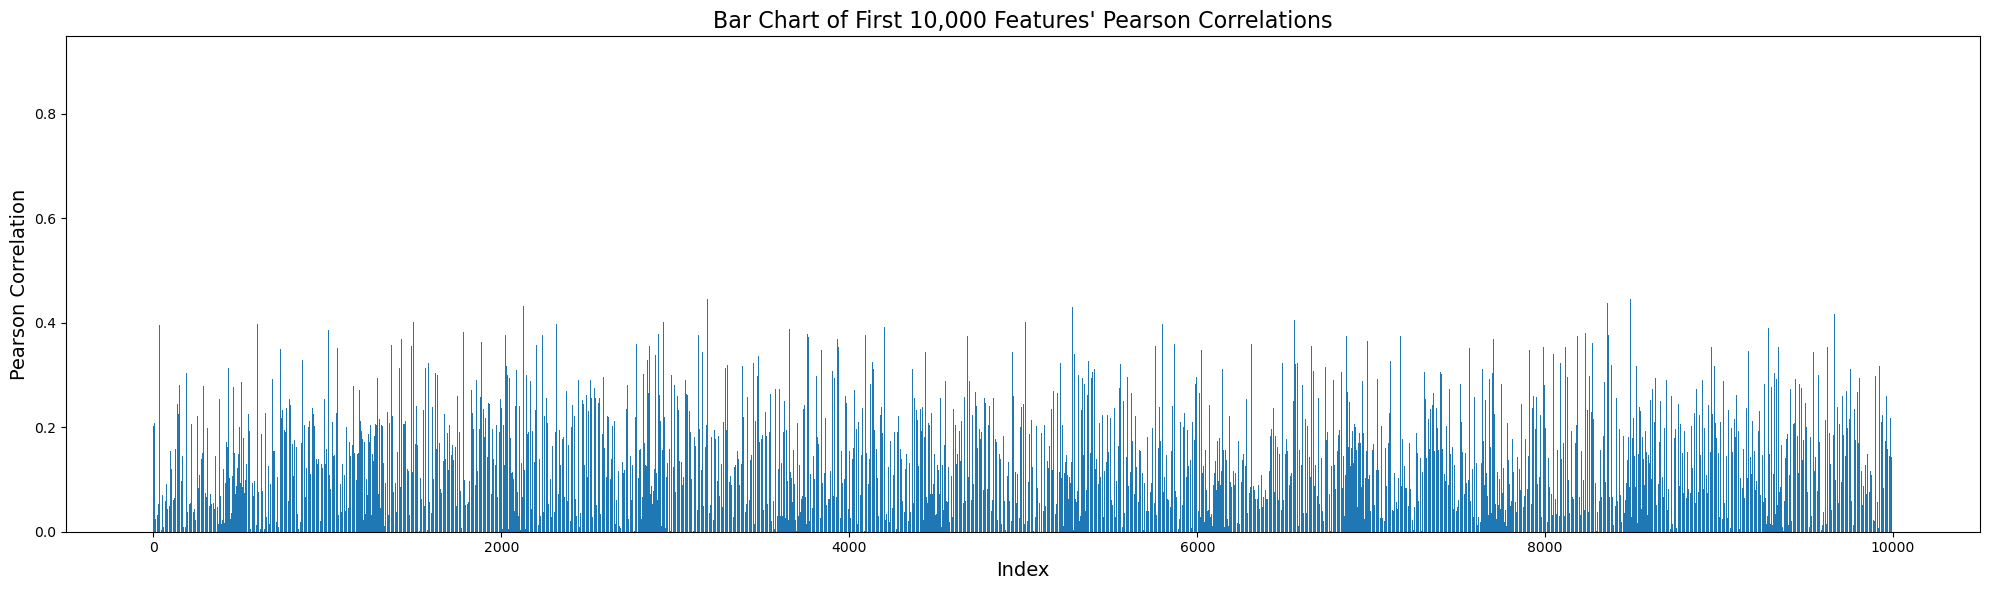

In [9]:
# Create a figure for the bar chart
plt.figure(figsize=(20, 6))

# Create the bar chart
plt.bar(range(len(correlations_subset)), correlations_subset.values)

# Set labels and title
plt.xlabel("Index", fontsize=14)
plt.ylabel("Pearson Correlation", fontsize=14)
plt.title("Bar Chart of First 10,000 Features' Pearson Correlations", fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### Apply the pearson correlation filter

In [10]:
#Function that creates and returns a new dataframe based on an old one and correlation threshold

def returnNewDataframe(df, correlation_matrix, correlation_threshold):
    # Identify highly correlated features: Create a mask to identify which features have correlation 
    # above the threshold and less than 1.00
    high_corr_mask = (correlation_matrix.abs() > correlation_threshold) & (correlation_matrix.abs() < 1.00).any()

    # Create a Set of Features to Remove
    features_to_drop = set()
    for feature in high_corr_mask.columns:
        correlated_features = high_corr_mask.index[high_corr_mask[feature]].tolist()
        for correlated_feature in correlated_features:
            if correlated_feature != feature:
                features_to_drop.add(correlated_feature)

    # Remove redundant features and return the dataframe
    return df.drop(columns=features_to_drop)

### Set pearson correlation threshold (target -> 55 - 110 features)

In [11]:
# Set a threshold for correlation filter
correlation_threshold = 0.4  # Adjust this threshold as needed

### Create the new dataframe based on the pearson correlation filter's threshold

In [12]:
df_new = returnNewDataframe(df, correlation_matrix, correlation_threshold)

# Rename the new DataFrame
df = df_new

df

,1555989_at,1560652_at,1569532_a_at,200740_s_at,201250_s_at,201542_at,202018_s_at,202284_s_at,202468_s_at,202804_at,...,230233_at,232075_at,234983_at,235201_at,238058_at,37152_at,41220_at,48580_at,Target,Tissue
0,996.5,65.9,34.6,6744.9,1251.0,2742.9,19.9,1859.9,971.9,1540.8,...,642.7,1338.5,1096.2,1328.9,776.2,2491.7,7147.1,1740.1,0,Kidney
1,256.4,27.2,37.8,10406.3,3922.1,2549.5,65.0,2976.2,559.2,2251.7,...,462.6,1377.0,3055.7,123.6,1783.8,1275.2,19373.9,1090.1,0,Kidney
2,458.8,273.5,260.9,3829.7,1883.9,3294.8,120.9,1659.5,304.3,1485.9,...,1334.9,971.0,1099.8,1050.8,1128.2,1571.1,6690.9,1273.8,0,Kidney
3,892.1,82.2,52.8,4722.4,2769.6,2498.4,51.4,2682.4,1061.5,1420.3,...,1995.3,1032.8,1859.1,1369.6,937.7,1769.4,6865.6,1430.2,0,Kidney
4,830.2,90.6,66.9,4245.3,3166.8,3128.0,85.1,2344.0,1299.1,1708.6,...,1033.1,2434.4,2615.9,908.3,2424.5,1493.6,10411.0,2027.2,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,265.6,29.3,15.6,3714.9,2220.6,2002.5,12.9,1990.5,1586.5,1880.9,...,710.1,1242.3,1766.5,479.4,1076.8,2438.2,7755.0,1563.0,1,Colon
542,368.6,130.0,92.3,5789.9,1426.7,3110.0,14.4,930.4,1130.6,1756.3,...,4502.5,2116.4,1533.0,133.2,1133.0,1827.5,9934.7,1418.1,1,Colon
543,459.2,56.3,5955.6,5267.0,970.7,2510.7,54.5,1929.8,1204.1,2263.0,...,1268.1,1299.6,1367.2,289.0,1027.7,1831.6,9837.6,2379.7,1,Colon
544,457.7,93.7,85.6,2725.9,865.4,2650.6,16.0,3191.4,1140.2,1974.0,...,671.1,1954.4,2054.8,628.8,1315.6,2077.2,10719.9,2245.5,1,Colon


### Export the high pearson correlation filtered dataset to .csv file

In [13]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Pearson Correlation\The colon-kidney high pearson correlation filtered dataset.csv"
df.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Pearson Correlation\The colon-kidney high pearson correlation filtered dataset.csv


### Transform outliers

In [14]:
# Function that tranforms outliers given a dataframe
def cap_outliers_iqr(df, threshold=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col in df_capped.columns and pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        else:
            print(f"Warning: Column '{col}' not found or is not numeric. Skipping.")
    return df_capped

In [15]:
# Transform outliers
df_capped = cap_outliers_iqr(df)
df_capped

,1555989_at,1560652_at,1569532_a_at,200740_s_at,201250_s_at,201542_at,202018_s_at,202284_s_at,202468_s_at,202804_at,...,230233_at,232075_at,234983_at,235201_at,238058_at,37152_at,41220_at,48580_at,Target,Tissue
0,996.5,65.9000,34.600,6744.90,1251.0,2742.9,19.9,1859.9,971.9,1540.8,...,642.7,1338.5,1096.2,1328.9,776.2,2491.7,7147.1000,1740.1,0.0,Kidney
1,256.4,27.2000,37.800,7136.55,3922.1,2549.5,65.0,2976.2,559.2,2251.7,...,462.6,1377.0,3055.7,123.6,1783.8,1275.2,16327.5875,1090.1,0.0,Kidney
2,458.8,251.4375,260.900,3829.70,1883.9,3294.8,120.9,1659.5,304.3,1485.9,...,1334.9,971.0,1099.8,1050.8,1128.2,1571.1,6690.9000,1273.8,0.0,Kidney
3,892.1,82.2000,52.800,4722.40,2769.6,2498.4,51.4,2682.4,1061.5,1420.3,...,1995.3,1032.8,1859.1,1369.6,937.7,1769.4,6865.6000,1430.2,0.0,Kidney
4,830.2,90.6000,66.900,4245.30,3166.8,3128.0,85.1,2344.0,1299.1,1708.6,...,1033.1,2434.4,2615.9,908.3,2424.5,1493.6,10411.0000,2027.2,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,265.6,29.3000,15.600,3714.90,2220.6,2002.5,12.9,1990.5,1586.5,1880.9,...,710.1,1242.3,1766.5,479.4,1076.8,2438.2,7755.0000,1563.0,1.0,Colon
542,368.6,130.0000,92.300,5789.90,1426.7,3110.0,14.4,930.4,1130.6,1756.3,...,2863.7,2116.4,1533.0,133.2,1133.0,1827.5,9934.7000,1418.1,1.0,Colon
543,459.2,56.3000,321.575,5267.00,970.7,2510.7,54.5,1929.8,1204.1,2263.0,...,1268.1,1299.6,1367.2,289.0,1027.7,1831.6,9837.6000,2379.7,1.0,Colon
544,457.7,93.7000,85.600,2725.90,865.4,2650.6,16.0,3191.4,1140.2,1974.0,...,671.1,1954.4,2054.8,628.8,1315.6,2077.2,10719.9000,2245.5,1.0,Colon


### Check if "Transform Outliers" worked: Count how many elements are different between dataframes. If 0 nothing happened

In [16]:
# Compare element-wise and count differences
num_differences = (df != df_capped).sum().sum()

# Print results
if num_differences > 0:
    print(f"The tranformation of outliers worked. The amount of outliers that has been transformed is: {num_differences}")
else:
    print("No values transformed during outliers transformation phase")

The tranformation of outliers worked. The amount of outliers that has been transformed is: 2009


### Export the dataset to .csv file

In [17]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Pearson Correlation\The colon-kidney high pearson correlation filtered capped dataset.csv"
df_capped.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Pearson Correlation\The colon-kidney high pearson correlation filtered capped dataset.csv


### End time

In [18]:
# End time
end_time = time.time()

### Elapsed time

In [19]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for High Pearson Correlation Dataset: {elapsed_time:.2f} seconds")

Elapsed time for High Pearson Correlation Dataset: 179.14 seconds
